# Vegetable Classification for XIAO ESP32S3

Train a lightweight CNN to classify 10 common fridge vegetables, then convert to TFLite INT8 for deployment on XIAO ESP32S3.

In [40]:
# Cell 1: Imports and Configuration
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Configuration
IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS = 100
NUM_CLASSES = 10
CONFIDENCE_THRESHOLD = 0.3  # Below this, output "Object not known"
SEED = 42

SELECTED_CLASSES = [
    'Bell pepper', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber',
    'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato'
]

BASE_DIR = os.path.join('..', 'data', 'huggingface')
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
MODEL_DIR = '.'

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'Selected classes: {SELECTED_CLASSES}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')

TensorFlow version: 2.18.0
Selected classes: ['Bell pepper', 'Broccoli', 'Cabbage', 'Carrot', 'Cucumber', 'Eggplant', 'Garlic', 'Onion', 'Potato', 'Tomato']
Confidence threshold: 0.3


In [14]:
# Cell 2: Data Loading and Exploration

# Check available classes and sample counts
print('=== Training Set ===')
for cls in SELECTED_CLASSES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.exists(cls_path):
        count = len(os.listdir(cls_path))
        print(f'  {cls}: {count} images')
    else:
        print(f'  {cls}: NOT FOUND')

print('\n=== Validation Set ===')
for cls in SELECTED_CLASSES:
    cls_path = os.path.join(VAL_DIR, cls)
    if os.path.exists(cls_path):
        count = len(os.listdir(cls_path))
        print(f'  {cls}: {count} images')
    else:
        print(f'  {cls}: NOT FOUND')

=== Training Set ===
  Bell pepper: 90 images
  Broccoli: 80 images
  Cabbage: 92 images
  Carrot: 82 images
  Cucumber: 94 images
  Eggplant: 84 images
  Garlic: 92 images
  Onion: 94 images
  Potato: 77 images
  Tomato: 92 images

=== Validation Set ===
  Bell pepper: 9 images
  Broccoli: 17 images
  Cabbage: 10 images
  Carrot: 9 images
  Cucumber: 10 images
  Eggplant: 10 images
  Garlic: 10 images
  Onion: 10 images
  Potato: 10 images
  Tomato: 10 images


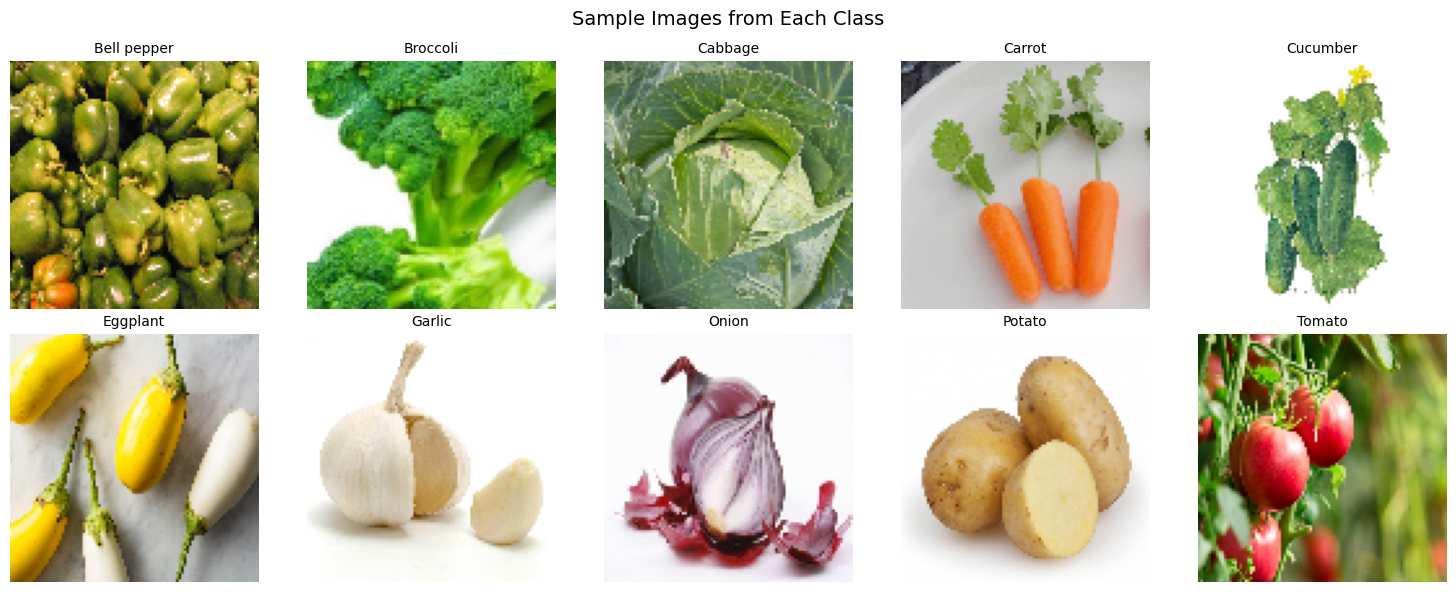

In [15]:
# Cell 2b: Visualize sample images

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, cls in enumerate(SELECTED_CLASSES):
    ax = axes[i // 5, i % 5]
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_name = os.listdir(cls_path)[0]
    img = keras.utils.load_img(
        os.path.join(cls_path, img_name),
        target_size=(IMG_SIZE, IMG_SIZE)
    )
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Images from Each Class', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Cell 3: Data Augmentation and Preprocessing

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode='categorical',
    seed=SEED,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    classes=SELECTED_CLASSES,
    class_mode='categorical',
    seed=SEED,
    shuffle=False
)

print(f'\nTraining samples: {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Class indices: {train_generator.class_indices}')

Found 877 images belonging to 10 classes.
Found 105 images belonging to 10 classes.

Training samples: 877
Validation samples: 105
Class indices: {'Bell pepper': 0, 'Broccoli': 1, 'Cabbage': 2, 'Carrot': 3, 'Cucumber': 4, 'Eggplant': 5, 'Garlic': 6, 'Onion': 7, 'Potato': 8, 'Tomato': 9}


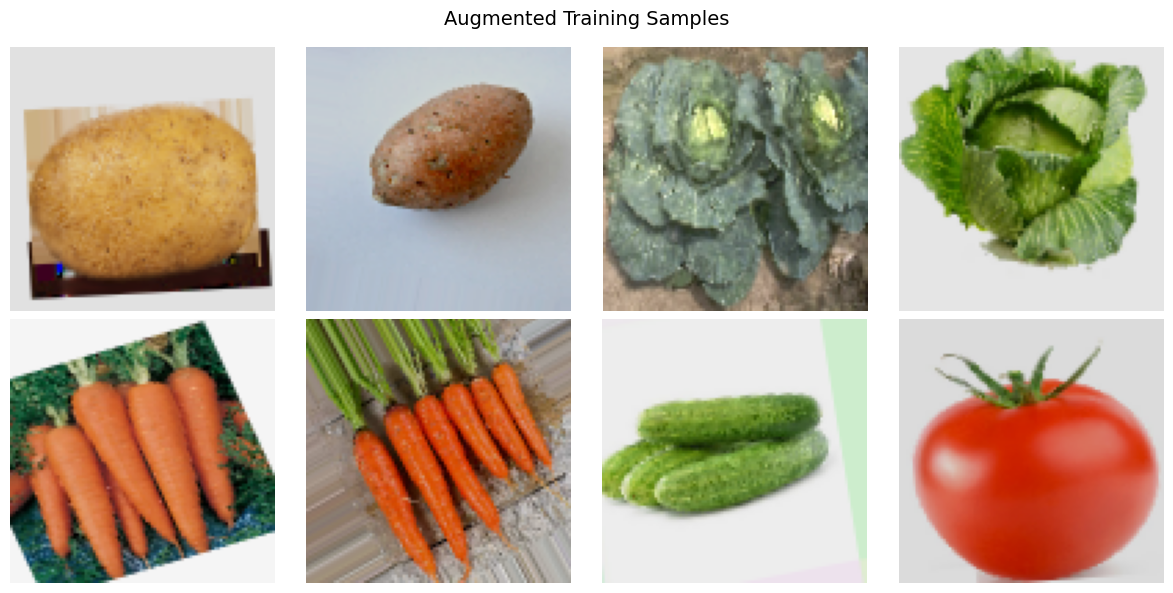

In [17]:
# Cell 3b: Visualize augmented images

sample_batch, _ = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[i])
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# Cell 4: Model Architecture

def depthwise_sep_conv(x, filters, stride=2):
    """Depthwise separable convolution block."""
    x = layers.DepthwiseConv2D(3, strides=stride, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_tiny_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    """Tiny CNN optimized for ESP32S3 deployment."""
    inputs = layers.Input(shape=input_shape)

    # Initial conv block
    x = layers.Conv2D(16, 3, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Depthwise separable conv blocks
    x = depthwise_sep_conv(x, 32, stride=2)
    x = depthwise_sep_conv(x, 64, stride=2)
    x = depthwise_sep_conv(x, 64, stride=2)

    # Classification head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='tiny_veggie_cnn')
    return model

model = build_tiny_cnn()
model.summary()

# Estimate model sizes
total_params = model.count_params()
print(f'\nTotal parameters: {total_params:,}')
print(f'Estimated float32 size: {total_params * 4 / 1024:.1f} KB')
print(f'Estimated INT8 size: {total_params / 1024:.1f} KB')

Model: "tiny_veggie_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_3              │ (None, 24, 24, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 24, 24, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_4              │ (None, 12, 12, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_11 (ReLU)                 │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_5              │ (None, 6, 6, 64)       │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 6, 6, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_12 (ReLU)                 │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 9,898 (38.66 KB)

 Trainable params: 9,322 (36.41 KB)

 Non-trainable params: 576 (2.25 KB)


Total parameters: 9,898
Estimated float32 size: 38.7 KB
Estimated INT8 size: 9.7 KB


In [19]:
# Cell 5: Training

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=callbacks
)

# Save the trained model
model.save(os.path.join(MODEL_DIR, 'veggie_model.keras'))
print('Model saved.')

Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 602ms/step - accuracy: 0.0865 - loss: 2.4743 - val_accuracy: 0.1619 - val_loss: 2.2970 - learning_rate: 0.0010
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 525ms/step - accuracy: 0.2369 - loss: 2.0857 - val_accuracy: 0.1429 - val_loss: 2.2999 - learning_rate: 0.0010
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 536ms/step - accuracy: 0.2460 - loss: 1.9466 - val_accuracy: 0.0952 - val_loss: 2.3119 - learning_rate: 0.0010
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 546ms/step - accuracy: 0.3077 - loss: 1.8239 - val_accuracy: 0.0952 - val_loss: 2.3324 - learning_rate: 0.0010
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 557ms/step - accuracy: 0.3683 - loss: 1.6677 - val_accuracy: 0.0952 - val_loss: 2.3573 - learning_rate: 0.0010
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.3865 - loss: 1.6278
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 548ms/step - accuracy: 0.3867 - loss

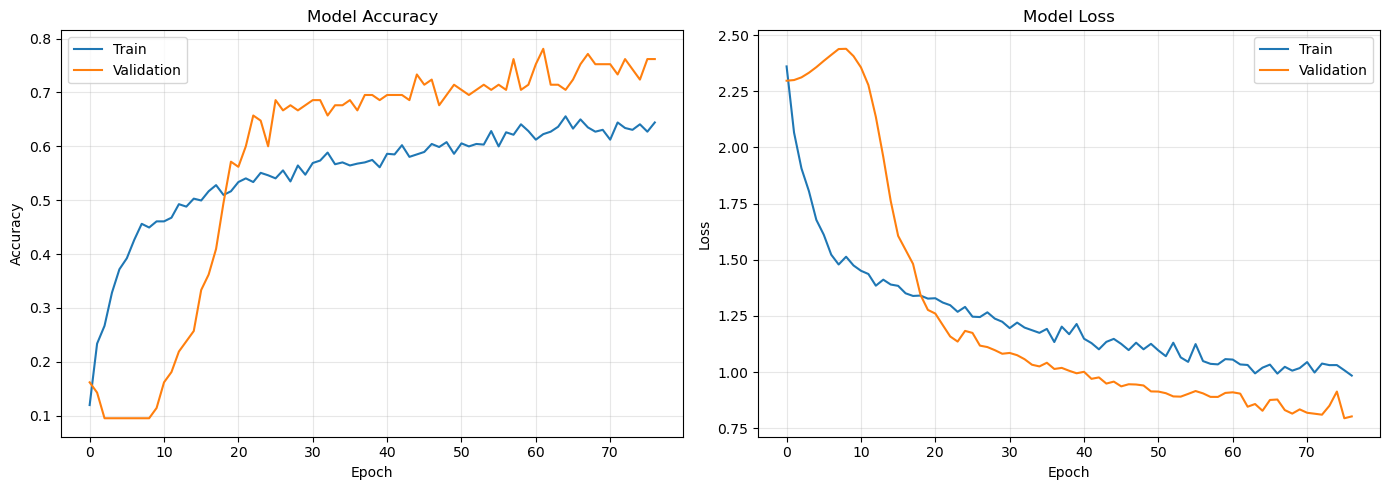

Best validation accuracy: 0.7810


In [23]:
# Cell 6: Training Visualization

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_accuracy'])
print(f'Best validation accuracy: {best_val_acc:.4f}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step
Predictions below confidence threshold (0.6): 5/105
These would be labeled "Object not known" at inference time.

=== Classification Report (confident predictions only) ===
              precision    recall  f1-score   support

 Bell pepper       0.53      0.89      0.67         9
    Broccoli       0.83      0.29      0.43        17
     Cabbage       1.00      0.80      0.89        10
      Carrot       1.00      1.00      1.00         9
    Cucumber       0.40      0.86      0.55         7
    Eggplant       0.82      0.90      0.86        10
      Garlic       0.83      1.00      0.91        10
       Onion       1.00      0.80      0.89        10
      Potato       0.88      0.88      0.88         8
      Tomato       0.88      0.70      0.78        10

    accuracy                           0.77       100
   macro avg       0.82      0.81      0.78       100
weighted avg       0.83      0.77      0.76       100



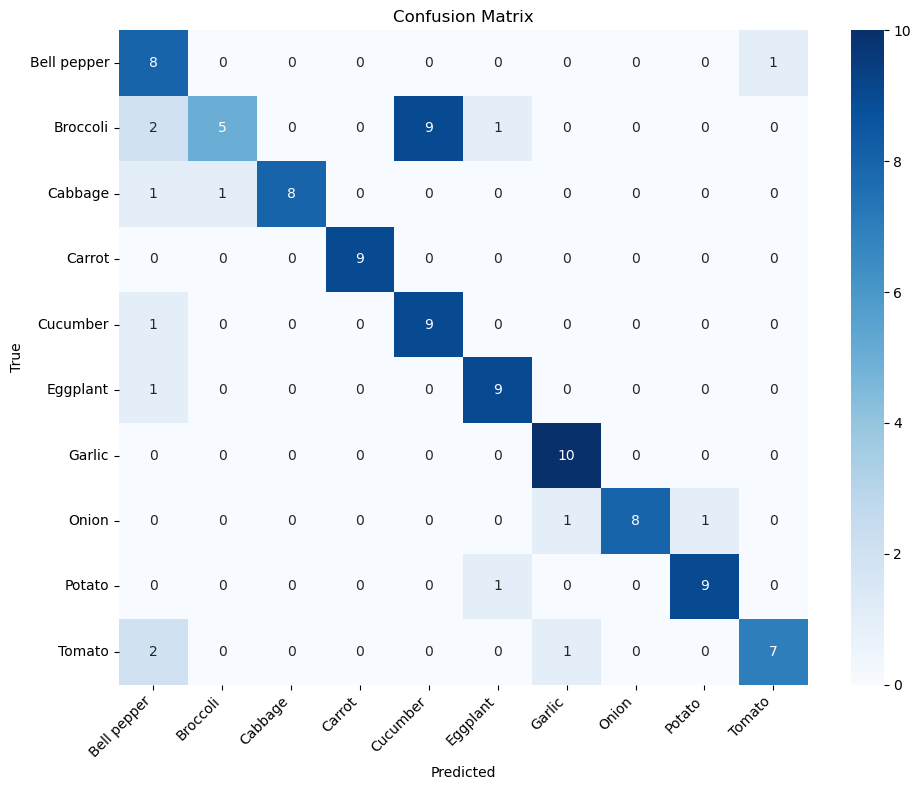

Overall accuracy (no threshold):   0.7810
Accuracy with threshold (unknown counted as wrong): 0.7333


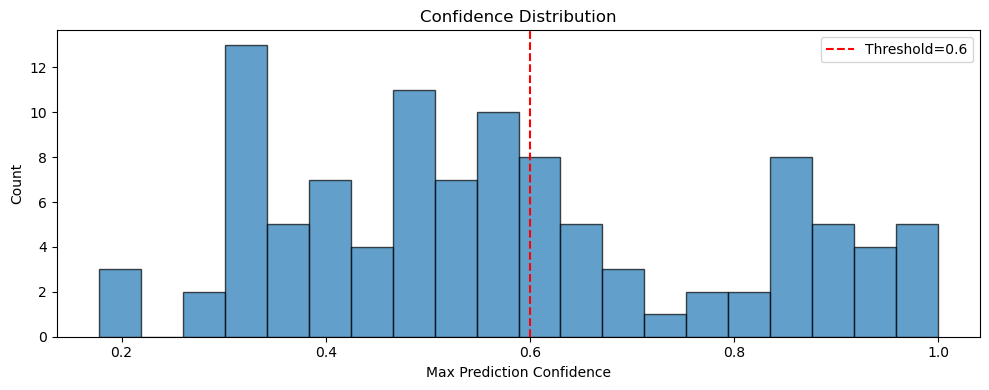

In [39]:
# Cell 7: Evaluation

# Reset generator and predict
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred_confidence = np.max(y_pred_probs, axis=1)
y_pred_class = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

# Apply confidence threshold: mark low-confidence as "Object not known"
# For evaluation, we treat unknown as a wrong prediction
y_pred = y_pred_class.copy()
unknown_mask = y_pred_confidence < 0.3
num_unknown = np.sum(unknown_mask)

class_names = list(val_generator.class_indices.keys())

print(f'Predictions below confidence threshold ({CONFIDENCE_THRESHOLD}): {num_unknown}/{len(y_true)}')
print(f'These would be labeled "Object not known" at inference time.\n')

# Classification report (on confident predictions only)
confident_mask = ~unknown_mask
if np.sum(confident_mask) > 0:
    # Only evaluate on samples where the model is confident
    # However, some classes may have zero samples after thresholding, which can lead to warnings in classification_report
    
    zero_sample_classes = []
    for i, cls in enumerate(class_names):
        if np.sum((y_true[confident_mask] == i)) == 0:
            zero_sample_classes.append(cls)
    if zero_sample_classes:
        print(f'Warning: The following classes have zero samples after applying the confidence threshold and will be ignored in the classification report: {zero_sample_classes}\n')
        class_names_for_report = [cls for cls in class_names if cls not in zero_sample_classes]
    else:
        class_names_for_report = class_names

    
    print('=== Classification Report (confident predictions only) ===')
    print(classification_report(
        y_true[confident_mask],
        y_pred[confident_mask],
        target_names=class_names_for_report,
        zero_division=0
    ))
    
# Confusion matrix (all predictions, ignoring threshold for visualization)
cm = confusion_matrix(y_true, y_pred_class)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Accuracy metrics
accuracy = np.sum(y_pred_class == y_true) / len(y_true)
accuracy_with_threshold = np.sum(y_pred[confident_mask] == y_true[confident_mask]) / len(y_true) if np.sum(confident_mask) > 0 else 0
print(f'Overall accuracy (no threshold):   {accuracy:.4f}')
print(f'Accuracy with threshold (unknown counted as wrong): {accuracy_with_threshold:.4f}')

# Confidence distribution
plt.figure(figsize=(10, 4))
plt.hist(y_pred_confidence, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=CONFIDENCE_THRESHOLD, color='r', linestyle='--', label=f'Threshold={CONFIDENCE_THRESHOLD}')
plt.xlabel('Max Prediction Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [41]:
# Cell 8: TFLite INT8 Conversion

# Representative dataset for INT8 calibration
def representative_data_gen():
    """Generate representative data for INT8 quantization calibration."""
    cal_generator = val_datagen.flow_from_directory(
        TRAIN_DIR,
        target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=1,
        classes=SELECTED_CLASSES,
        class_mode=None,
        seed=SEED,
        shuffle=True
    )
    for i in range(100):
        sample = next(cal_generator)
        yield [sample.astype(np.float32)]

# Convert to TFLite with full INT8 quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_model = converter.convert()

# Save TFLite model
tflite_path = os.path.join(MODEL_DIR, 'veggie_model.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

keras_size = os.path.getsize(os.path.join(MODEL_DIR, 'veggie_model.keras'))
tflite_size = os.path.getsize(tflite_path)
print(f'Keras model size:  {keras_size / 1024:.1f} KB')
print(f'TFLite INT8 size:  {tflite_size / 1024:.1f} KB')
print(f'Compression ratio: {keras_size / tflite_size:.1f}x')

INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpr1fhxsvr/assets


INFO:tensorflow:Assets written to: /var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpr1fhxsvr/assets


Saved artifact at '/var/folders/hy/gt2nwnn17vd1rbxpl53fp9hm0000gn/T/tmpr1fhxsvr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor_25')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  14393014416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14393014992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14393000208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14393014800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  14393015568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825233360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825234896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825235088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825234704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825233552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5825235472: T

W0000 00:00:1775775492.804743 23058907 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1775775492.804758 23058907 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.


Found 877 images belonging to 10 classes.
Keras model size:  221.9 KB
TFLite INT8 size:  23.1 KB
Compression ratio: 9.6x


fully_quantize: 0, inference_type: 6, input_inference_type: INT8, output_inference_type: INT8


In [42]:
# Cell 9: TFLite Model Validation

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print('=== TFLite Model Info ===')
print(f'Input shape:  {input_details[0]["shape"]}')
print(f'Input dtype:  {input_details[0]["dtype"]}')
print(f'Output shape: {output_details[0]["shape"]}')
print(f'Output dtype: {output_details[0]["dtype"]}')

# Get quantization parameters
input_scale, input_zero_point = input_details[0]['quantization']
output_scale, output_zero_point = output_details[0]['quantization']
print(f'\nInput quantization: scale={input_scale}, zero_point={input_zero_point}')
print(f'Output quantization: scale={output_scale}, zero_point={output_zero_point}')

# Run inference on validation set
val_eval_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=1,
    classes=SELECTED_CLASSES,
    class_mode='categorical',
    shuffle=False
)

tflite_preds = []
tflite_confs = []
tflite_true = []

for i in range(val_eval_gen.samples):
    img, label = next(val_eval_gen)
    # Quantize input: convert float [0,1] to int8
    img_int8 = (img / input_scale + input_zero_point).astype(np.int8)
    interpreter.set_tensor(input_details[0]['index'], img_int8)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    # Dequantize output to get probabilities
    output_float = (output.astype(np.float32) - output_zero_point) * output_scale
    tflite_preds.append(np.argmax(output_float))
    tflite_confs.append(np.max(output_float))
    tflite_true.append(np.argmax(label[0]))

tflite_preds = np.array(tflite_preds)
tflite_confs = np.array(tflite_confs)
tflite_true = np.array(tflite_true)

# Apply confidence threshold
tflite_unknown = tflite_confs < CONFIDENCE_THRESHOLD
tflite_confident = ~tflite_unknown

tflite_accuracy = np.sum(tflite_preds == tflite_true) / len(tflite_true)
tflite_accuracy_thresh = np.sum(tflite_preds[tflite_confident] == tflite_true[tflite_confident]) / len(tflite_true) if np.sum(tflite_confident) > 0 else 0

print(f'\n=== Accuracy Comparison ===')
print(f'Keras model (float32):      {accuracy:.4f}')
print(f'TFLite model (INT8):        {tflite_accuracy:.4f}')
print(f'Accuracy drop:              {(accuracy - tflite_accuracy) * 100:.2f}%')
print(f'\nWith confidence threshold ({CONFIDENCE_THRESHOLD}):')
print(f'  "Object not known" count: {np.sum(tflite_unknown)}/{len(tflite_true)}')
print(f'  Accuracy on confident:    {tflite_accuracy_thresh:.4f}')

=== TFLite Model Info ===
Input shape:  [ 1 96 96  3]
Input dtype:  <class 'numpy.int8'>
Output shape: [ 1 10]
Output dtype: <class 'numpy.int8'>

Input quantization: scale=0.003921568859368563, zero_point=-128
Output quantization: scale=0.00390625, zero_point=-128
Found 105 images belonging to 10 classes.

=== Accuracy Comparison ===
Keras model (float32):      0.7810
TFLite model (INT8):        0.7429
Accuracy drop:              3.81%

With confidence threshold (0.3):
  "Object not known" count: 7/105
  Accuracy on confident:    0.7143


In [43]:
# Cell 10: Export C Header for ESP32

# Export model as C header
def export_c_header(tflite_path, header_path, array_name='model_data'):
    """Convert TFLite model to C header file for ESP32 deployment."""
    with open(tflite_path, 'rb') as f:
        data = f.read()

    with open(header_path, 'w') as f:
        f.write('#ifndef MODEL_DATA_H\n')
        f.write('#define MODEL_DATA_H\n\n')
        f.write(f'const unsigned int {array_name}_len = {len(data)};\n\n')
        f.write(f'alignas(16) const unsigned char {array_name}[] = {{\n')
        for i in range(0, len(data), 12):
            chunk = data[i:i+12]
            hex_vals = ', '.join(f'0x{b:02x}' for b in chunk)
            f.write(f'  {hex_vals},\n')
        f.write('};\n\n')
        f.write('#endif // MODEL_DATA_H\n')

    print(f'Model header written to: {header_path}')
    print(f'Array size: {len(data)} bytes')

# Export labels header with confidence threshold
def export_labels_header(class_names, header_path, threshold=CONFIDENCE_THRESHOLD):
    """Export class labels as C header file with confidence threshold."""
    with open(header_path, 'w') as f:
        f.write('#ifndef LABELS_H\n')
        f.write('#define LABELS_H\n\n')
        f.write(f'const int NUM_CLASSES = {len(class_names)};\n')
        f.write(f'const float CONFIDENCE_THRESHOLD = {threshold}f;\n')
        f.write('const char* UNKNOWN_LABEL = "Object not known";\n\n')
        f.write('const char* LABELS[] = {\n')
        for name in class_names:
            f.write(f'  "{name}",\n')
        f.write('};\n\n')
        f.write('// Usage: if (max_confidence < CONFIDENCE_THRESHOLD) return UNKNOWN_LABEL;\n')
        f.write('//        else return LABELS[predicted_class];\n\n')
        f.write('#endif // LABELS_H\n')

    print(f'Labels header written to: {header_path}')

# Generate headers
export_c_header(tflite_path, os.path.join(MODEL_DIR, 'model_data.h'))
export_labels_header(class_names, os.path.join(MODEL_DIR, 'labels.h'))

print(f'\n=== Final Summary ===')
print(f'TFLite model size: {tflite_size / 1024:.1f} KB')
print(f'Within ESP32S3 budget (500 KB): {"YES" if tflite_size < 500 * 1024 else "NO"}')
print(f'Confidence threshold: {CONFIDENCE_THRESHOLD}')

Model header written to: ./model_data.h
Array size: 23616 bytes
Labels header written to: ./labels.h

=== Final Summary ===
TFLite model size: 23.1 KB
Within ESP32S3 budget (500 KB): YES
Confidence threshold: 0.3


## ESP32S3 Deployment Notes

### Model Specs
- **Input**: 96x96 RGB image, INT8 quantized
- **Output**: 10-class softmax (INT8)
- **Confidence threshold**: 0.3 — below this, output **"Object not known"**
- **Classes**: Bell pepper, Broccoli, Cabbage, Carrot, Cucumber, Eggplant, Garlic, Onion, Potato, Tomato

### Files for ESP32
- `model_data.h` - Model weights as C array
- `labels.h` - Class label strings + `CONFIDENCE_THRESHOLD` + `UNKNOWN_LABEL`

### Memory Requirements
- Model: ~25 KB (INT8 quantized)
- Input buffer: 96 x 96 x 3 = 27,648 bytes (~27 KB)
- Intermediate tensors (arena): ~50-100 KB
- **Total estimated**: ~150 KB (well within 8 MB PSRAM)

### Inference Logic on ESP32
```c
// After running inference:
float max_conf = get_max_output(output);
int pred_class = get_argmax(output);

if (max_conf < CONFIDENCE_THRESHOLD) {
    Serial.println(UNKNOWN_LABEL);  // "Object not known"
} else {
    Serial.println(LABELS[pred_class]);
}
```

### Integration with XIAO ESP32S3
1. Include `model_data.h` and `labels.h` in your Arduino/ESP-IDF project
2. Use TensorFlow Lite Micro library (`tflite-micro`)
3. Capture 96x96 RGB image from camera (OV2640)
4. Quantize pixel values using the input scale/zero_point from Cell 9
5. Run inference, dequantize output, check confidence threshold
6. If confidence >= threshold → output class label; otherwise → "Object not known"